In [ ]:
# =========================================================
# VERSION 1
# SENTIMENT ANALYSIS: 3-MODEL COMPARISON
# Models:
#   1) bert-base-uncased
#   2) ProsusAI/finbert
#   3) yiyanghkust/finbert-tone
#
# Features:
#   - Google Drive dataset download
#   - Text cleaning
#   - Train / Validation / Test split
#   - GPU support
#   - Faster training setup
#   - Accuracy / Precision / Recall / F1
#   - Confusion Matrix
#   - ROC-AUC (One-vs-Rest)
#   - Loss Curve
#   - Error Analysis
#   - Model Comparison Charts
# =========================================================


In [49]:
# =========================================================
# CELL 1: Install packages (Run once if needed)
# =========================================================
!pip install -q transformers datasets accelerate evaluate scikit-learn pandas numpy matplotlib seaborn gdown

In [50]:
# =========================================================
# CELL 2: Imports
# =========================================================
import os
import re
import html
import json
import random
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
    set_seed
)

In [51]:
# =========================================================
# CELL 3: Reproducibility + GPU Check
# =========================================================
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

if DEVICE == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Running on CPU.")

Using device: cuda
GPU Name: Tesla T4


In [52]:
# =========================================================
# CELL 4: Create output folders
# =========================================================
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/confusion_matrices", exist_ok=True)
os.makedirs("outputs/loss_curves", exist_ok=True)
os.makedirs("outputs/roc_curves", exist_ok=True)
os.makedirs("outputs/error_analysis", exist_ok=True)
os.makedirs("outputs/classification_reports", exist_ok=True)
os.makedirs("saved_models", exist_ok=True)

In [53]:
# =========================================================
# CELL 5: DOWNLOAD DATASET (FIXED)
# =========================================================
import os

file_id = "1UVgxPtS9_dONmjiJvjUwbXyOJVw4sH6R"
url = f"https://drive.google.com/uc?id={file_id}"
out_file = "dataset.csv"

# যদি আগের ফাইল থাকে, তবে তা রিমুভ করে নতুন লিঙ্ক থেকে ডাউনলোড নিশ্চিত করা
if os.path.exists(out_file):
    os.remove(out_file)
    print(f"Old {out_file} removed to download the new version.")

print("Downloading new dataset...")
gdown.download(url, out_file, quiet=False)

Old dataset.csv removed to download the new version.


Downloading...
From (original): https://drive.google.com/uc?id=1UVgxPtS9_dONmjiJvjUwbXyOJVw4sH6R
From (redirected): https://drive.google.com/uc?id=1UVgxPtS9_dONmjiJvjUwbXyOJVw4sH6R&confirm=t&uuid=ac3f5faa-3916-4922-b9dd-3dd0afae3870
To: /content/dataset.csv
100%|██████████| 123M/123M [00:02<00:00, 51.4MB/s]


'dataset.csv'

In [54]:
# =========================================================
# CELL 6: Load dataset
# =========================================================
df = pd.read_csv(out_file)

# headline + clean_text combine করে নতুন text column
df["text"] = df["headline"].fillna("") + " " + df["clean_text"].fillna("")

TEXT_COL = "text"
LABEL_COL = "Sentiment_Label"

df = df[[TEXT_COL, LABEL_COL]].copy()
df = df.dropna(subset=[TEXT_COL, LABEL_COL])

print("\n--- Dataset Loaded ---")
print("Shape:", df.shape)
print(df.head())


--- Dataset Loaded ---
Shape: (1703, 2)
                                                text Sentiment_Label
0  BB probe into Union Bank: â€˜S Alam stafferâ€™...        Negative
1  Workers block highway for 2nd day, 15-km tailb...        Negative
2  Bangladesh holds just 0.01% of global potato m...         Neutral
3  Farmers reduce potato acreage for next year af...        Negative
4  Investment Corporation of Bangladesh holds 49t...         Neutral


In [55]:
# =========================================================
# CELL 7: Text cleaning
# =========================================================
def fix_encoding(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = text.replace("Ã¢â‚¬â„¢", "'").replace("Ã¢â‚¬Ëœ", "'")
    text = text.replace("Ã¢â‚¬œ", '"').replace("Ã¢â‚¬\x9d", '"')
    text = text.replace("Ã‚", " ").replace("Â", " ")
    text = text.replace("_x000d_", " ")
    return text

def remove_repeated_words(text):
    words = text.split()
    cleaned = []
    for w in words:
        if len(cleaned) >= 1 and cleaned[-1].lower() == w.lower():
            continue
        cleaned.append(w)
    return " ".join(cleaned)

def normalize_text(text):
    if not isinstance(text, str):
        return ""
    text = fix_encoding(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.lower().strip()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^\w\s\.\,\%\-\$\(\)\'\":;/]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = remove_repeated_words(text)
    return text

df["clean_text"] = df[TEXT_COL].astype(str).apply(normalize_text)

# ছোট/garbage text remove
df = df[df["clean_text"].str.len() >= 5].copy()

# duplicate remove
df = df.drop_duplicates(subset=["clean_text", LABEL_COL]).reset_index(drop=True)

print("\nAfter cleaning:", df.shape)
print(df[["clean_text", LABEL_COL]].head())


After cleaning: (1703, 3)
                                          clean_text Sentiment_Label
0  bb probe into union bank: â s alam stafferâ tm...        Negative
1  workers block highway for 2nd day, 15-km tailb...        Negative
2  bangladesh holds just 0.01% of global potato m...         Neutral
3  farmers reduce potato acreage for next year af...        Negative
4  investment corporation of bangladesh holds 49t...         Neutral



Label distribution:
Sentiment_Label
Positive    660
Neutral     529
Negative    506
Name: count, dtype: int64


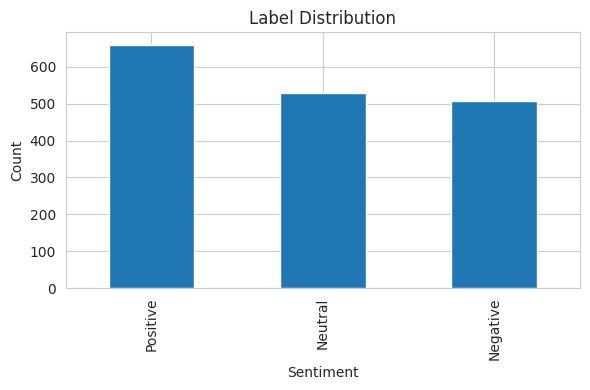

In [56]:
# =========================================================
# CELL 8: Label mapping + label distribution
# =========================================================
label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {v: k for k, v in label2id.items()}

df = df[df[LABEL_COL].isin(label2id.keys())].copy()
df["label"] = df[LABEL_COL].map(label2id)

print("\nLabel distribution:")
print(df[LABEL_COL].value_counts())

plt.figure(figsize=(6, 4))
df[LABEL_COL].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/label_distribution.png", dpi=300)
plt.show()

In [57]:
# =========================================================
# CELL 9: Train / Validation / Test split
# =========================================================
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("\nTrain:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label dist:")
print(train_df[LABEL_COL].value_counts())

print("\nValidation label dist:")
print(val_df[LABEL_COL].value_counts())

print("\nTest label dist:")
print(test_df[LABEL_COL].value_counts())


Train: (1356, 4)
Validation: (169, 4)
Test: (170, 4)

Train label dist:
Sentiment_Label
Positive    528
Neutral     423
Negative    405
Name: count, dtype: int64

Validation label dist:
Sentiment_Label
Positive    66
Neutral     53
Negative    50
Name: count, dtype: int64

Test label dist:
Sentiment_Label
Positive    66
Neutral     53
Negative    51
Name: count, dtype: int64


In [58]:
# =========================================================
# CELL 10: Convert to Hugging Face Dataset
# =========================================================
train_base = Dataset.from_pandas(train_df[["clean_text", "label"]].reset_index(drop=True))
val_base   = Dataset.from_pandas(val_df[["clean_text", "label"]].reset_index(drop=True))
test_base  = Dataset.from_pandas(test_df[["clean_text", "label"]].reset_index(drop=True))

In [59]:
# =========================================================
# CELL 11: Metrics function
# =========================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

In [60]:
# =========================================================
# CELL 12: Model list
# =========================================================
model_names = [
    "bert-base-uncased",
    "ProsusAI/finbert",
    "yiyanghkust/finbert-tone"
]

all_results = []

In [61]:
# =========================================================
# CELL 13: Helper functions for saving visuals and reports
# =========================================================
def make_safe_name(model_name):
    return model_name.replace("/", "_").replace("-", "_")

def save_confusion_matrix(y_true, y_pred, class_names, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

def save_loss_curve(trainer, title, save_path):
    logs = trainer.state.log_history

    train_epochs, train_losses = [], []
    eval_epochs, eval_losses = [], []

    for log in logs:
        if "loss" in log and "epoch" in log and "eval_loss" not in log:
            train_epochs.append(log["epoch"])
            train_losses.append(log["loss"])
        if "eval_loss" in log and "epoch" in log:
            eval_epochs.append(log["epoch"])
            eval_losses.append(log["eval_loss"])

    plt.figure(figsize=(7, 5))
    if train_losses:
        plt.plot(train_epochs, train_losses, marker="o", label="Train Loss")
    if eval_losses:
        plt.plot(eval_epochs, eval_losses, marker="o", label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

def save_multiclass_roc_auc(y_true, probs, class_names, title, save_path):
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    plt.figure(figsize=(7, 6))

    auc_scores = {}
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores[class_name] = roc_auc
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="red")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

    return auc_scores

def save_error_analysis(texts, y_true, y_pred, id2label, save_path, n=10):
    err_df = pd.DataFrame({
        "text": list(texts),
        "true_label": [id2label[i] for i in y_true],
        "pred_label": [id2label[i] for i in y_pred]
    })
    err_df = err_df[err_df["true_label"] != err_df["pred_label"]].copy()
    err_df.head(n).to_csv(save_path, index=False)
    return err_df

In [62]:
# =========================================================
# CELL 14: Training loop
# =========================================================
for model_name in model_names:
    print("\n" + "=" * 80)
    print(f"Running model: {model_name}")
    print("=" * 80)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(
            examples["clean_text"],
            truncation=True,
            max_length=96
        )

    train_ds = train_base.map(tokenize_function, batched=True)
    val_ds   = val_base.map(tokenize_function, batched=True)
    test_ds  = test_base.map(tokenize_function, batched=True)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    safe_name = make_safe_name(model_name)

    try:
        training_args = TrainingArguments(
            output_dir=f"./outputs/output_{safe_name}",
            evaluation_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch",
            per_device_train_batch_size=8,
            per_device_eval_batch_size=16,
            num_train_epochs=3,
            learning_rate=2e-5,
            weight_decay=0.01,
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            greater_is_better=True,
            save_total_limit=2,
            fp16=torch.cuda.is_available(),
            report_to="none"
        )
    except TypeError:
        training_args = TrainingArguments(
            output_dir=f"./outputs/output_{safe_name}",
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch",
            per_device_train_batch_size=8,
            per_device_eval_batch_size=16,
            num_train_epochs=3,
            learning_rate=2e-5,
            weight_decay=0.01,
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            greater_is_better=True,
            save_total_limit=2,
            fp16=torch.cuda.is_available(),
            report_to="none"
        )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # -------- Train metrics --------
    train_output = trainer.predict(train_ds)
    train_logits = train_output.predictions
    train_labels = train_output.label_ids
    train_preds = np.argmax(train_logits, axis=1)

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1_macro = f1_score(train_labels, train_preds, average="macro")
    train_f1_weighted = f1_score(train_labels, train_preds, average="weighted")

    # -------- Validation metrics --------
    val_output = trainer.predict(val_ds)
    val_logits = val_output.predictions
    val_labels = val_output.label_ids
    val_preds = np.argmax(val_logits, axis=1)

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1_macro = f1_score(val_labels, val_preds, average="macro")
    val_f1_weighted = f1_score(val_labels, val_preds, average="weighted")

    # -------- Test metrics --------
    test_output = trainer.predict(test_ds)
    test_logits = test_output.predictions
    test_labels = test_output.label_ids
    test_preds = np.argmax(test_logits, axis=1)
    test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()

    test_acc = accuracy_score(test_labels, test_preds)
    test_f1_macro = f1_score(test_labels, test_preds, average="macro")
    test_f1_weighted = f1_score(test_labels, test_preds, average="weighted")

    print("\nTrain Accuracy:", train_acc)
    print("Validation Accuracy:", val_acc)
    print("Test Accuracy:", test_acc)

    print("\nTest F1 Macro:", test_f1_macro)
    print("Test F1 Weighted:", test_f1_weighted)

    class_report_text = classification_report(
        test_labels,
        test_preds,
        target_names=[id2label[i] for i in range(3)]
    )
    print("\nClassification Report:")
    print(class_report_text)

    with open(f"outputs/classification_reports/{safe_name}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(class_report_text)

    # -------- Save visuals --------
    save_confusion_matrix(
        test_labels,
        test_preds,
        ["Negative", "Neutral", "Positive"],
        title=f"Confusion Matrix - {model_name}",
        save_path=f"outputs/confusion_matrices/{safe_name}_confusion_matrix.png"
    )

    save_loss_curve(
        trainer,
        title=f"Train vs Validation Loss - {model_name}",
        save_path=f"outputs/loss_curves/{safe_name}_loss_curve.png"
    )

    roc_auc_scores = save_multiclass_roc_auc(
        test_labels,
        test_probs,
        ["Negative", "Neutral", "Positive"],
        title=f"Multiclass ROC-AUC - {model_name}",
        save_path=f"outputs/roc_curves/{safe_name}_roc_auc.png"
    )

    error_df = save_error_analysis(
        texts=test_df["clean_text"].reset_index(drop=True),
        y_true=test_labels,
        y_pred=test_preds,
        id2label=id2label,
        save_path=f"outputs/error_analysis/{safe_name}_error_analysis.csv",
        n=10
    )

    # -------- Save model --------
    save_dir = f"saved_models/{safe_name}"
    trainer.save_model(save_dir)
    tokenizer.save_pretrained(save_dir)

    # -------- Store results --------
    all_results.append({
        "model": model_name,
        "safe_name": safe_name,

        "train_accuracy": train_acc,
        "train_f1_macro": train_f1_macro,
        "train_f1_weighted": train_f1_weighted,

        "val_accuracy": val_acc,
        "val_f1_macro": val_f1_macro,
        "val_f1_weighted": val_f1_weighted,

        "test_accuracy": test_acc,
        "test_f1_macro": test_f1_macro,
        "test_f1_weighted": test_f1_weighted,

        "test_roc_auc_ovr_macro": roc_auc_score(
            label_binarize(test_labels, classes=[0, 1, 2]),
            test_probs,
            average="macro",
            multi_class="ovr"
        ),

        "auc_negative": roc_auc_scores["Negative"],
        "auc_neutral": roc_auc_scores["Neutral"],
        "auc_positive": roc_auc_scores["Positive"],

        "num_test_errors": len(error_df)
    })

    print(f"\nSaved model to: {save_dir}")
    print(f"Saved confusion matrix: outputs/confusion_matrices/{safe_name}_confusion_matrix.png")
    print(f"Saved loss curve: outputs/loss_curves/{safe_name}_loss_curve.png")
    print(f"Saved ROC curve: outputs/roc_curves/{safe_name}_roc_auc.png")
    print(f"Saved error analysis: outputs/error_analysis/{safe_name}_error_analysis.csv")


Running model: bert-base-uncased


Map:   0%|          | 0/1356 [00:00<?, ? examples/s]

Map:   0%|          | 0/169 [00:00<?, ? examples/s]

Map:   0%|          | 0/170 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Train Accuracy: 0.7588495575221239
Validation Accuracy: 0.650887573964497
Test Accuracy: 0.6235294117647059

Test F1 Macro: 0.6229261371463206
Test F1 Weighted: 0.6247697184502365

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.69      0.64        51
     Neutral       0.55      0.60      0.58        53
    Positive       0.72      0.59      0.65        66

    accuracy                           0.62       170
   macro avg       0.63      0.63      0.62       170
weighted avg       0.63      0.62      0.62       170



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved model to: saved_models/yiyanghkust_finbert_tone
Saved confusion matrix: outputs/confusion_matrices/yiyanghkust_finbert_tone_confusion_matrix.png
Saved loss curve: outputs/loss_curves/yiyanghkust_finbert_tone_loss_curve.png
Saved ROC curve: outputs/roc_curves/yiyanghkust_finbert_tone_roc_auc.png
Saved error analysis: outputs/error_analysis/yiyanghkust_finbert_tone_error_analysis.csv


In [63]:
# =========================================================
# CELL 15: Final results table
# =========================================================
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by="test_f1_macro", ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
print(results_df)

results_df.to_csv("outputs/model_comparison_results.csv", index=False)
results_df.to_json("outputs/model_comparison_results.json", orient="records", indent=4)

print("\nSaved comparison table to: outputs/model_comparison_results.csv")


FINAL MODEL COMPARISON
                      model                 safe_name  train_accuracy  \
0         bert-base-uncased         bert_base_uncased        0.898968   
1          ProsusAI/finbert          ProsusAI_finbert        0.903392   
2  yiyanghkust/finbert-tone  yiyanghkust_finbert_tone        0.758850   

   train_f1_macro  train_f1_weighted  val_accuracy  val_f1_macro  \
0        0.897704           0.897988      0.698225      0.690269   
1        0.901738           0.902577      0.680473      0.668971   
2        0.758240           0.758579      0.650888      0.646863   

   val_f1_weighted  test_accuracy  test_f1_macro  test_f1_weighted  \
0         0.694508       0.711765       0.703822          0.707467   
1         0.675326       0.676471       0.675295          0.676850   
2         0.646687       0.623529       0.622926          0.624770   

   test_roc_auc_ovr_macro  auc_negative  auc_neutral  auc_positive  \
0                0.862900      0.902126     0.816965      0

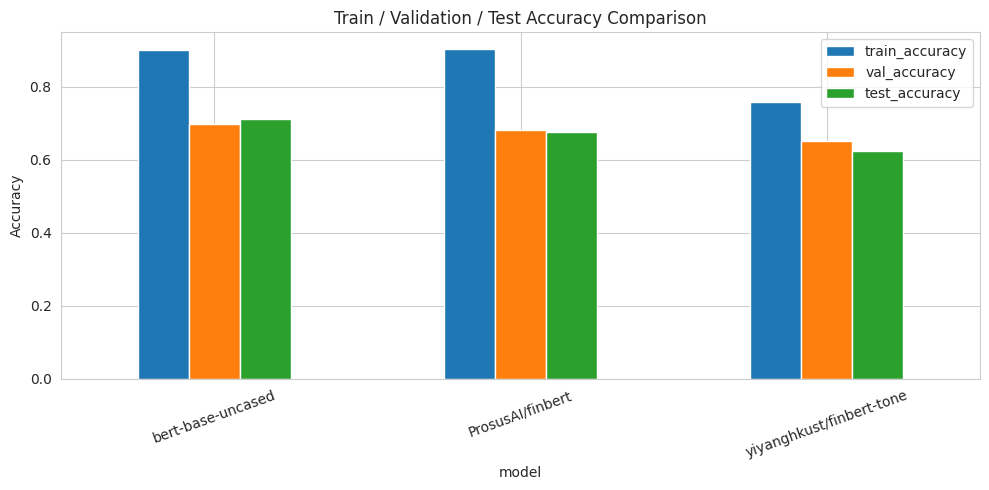

In [64]:
# =========================================================
# CELL 16: Accuracy comparison bar chart
# =========================================================
ax = results_df.plot(
    x="model",
    y=["train_accuracy", "val_accuracy", "test_accuracy"],
    kind="bar",
    figsize=(10, 5)
)
plt.title("Train / Validation / Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/model_accuracy_comparison.png", dpi=300)
plt.show()

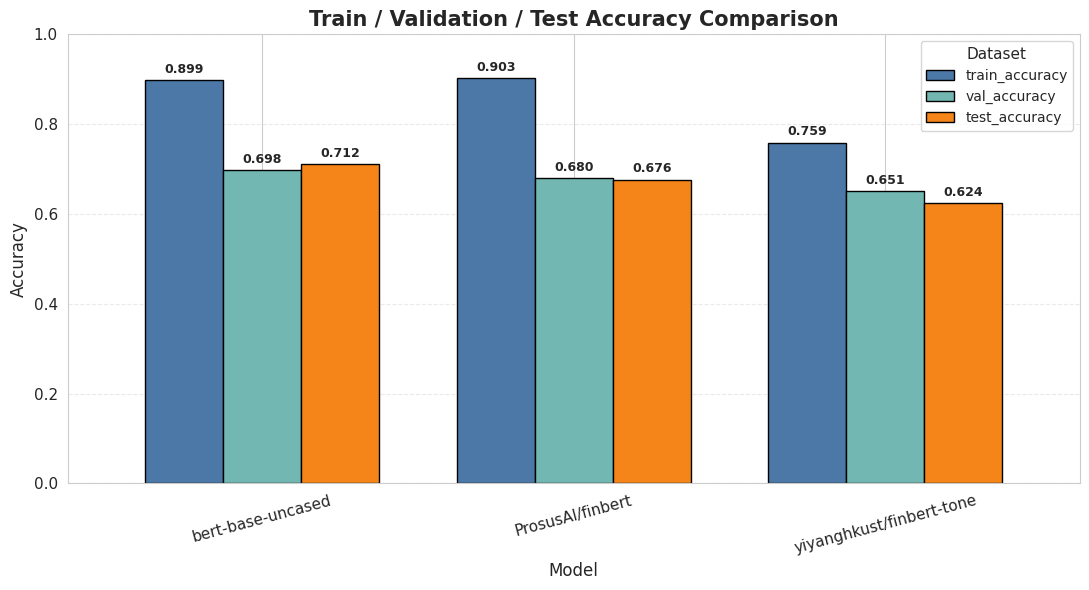

In [65]:
# =========================================================
# CELL 16: Accuracy comparison bar chart (Professional)
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

ax = results_df.plot(
    x="model",
    y=["train_accuracy", "val_accuracy", "test_accuracy"],
    kind="bar",
    figsize=(11, 6),
    color=["#4C78A8", "#72B7B2", "#F58518"],   # professional palette
    edgecolor="black",
    width=0.75
)

plt.title("Train / Validation / Test Accuracy Comparison", fontsize=15, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=15, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, 1.0)
plt.legend(title="Dataset", fontsize=10, title_fontsize=11, loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# value labels on top
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/model_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

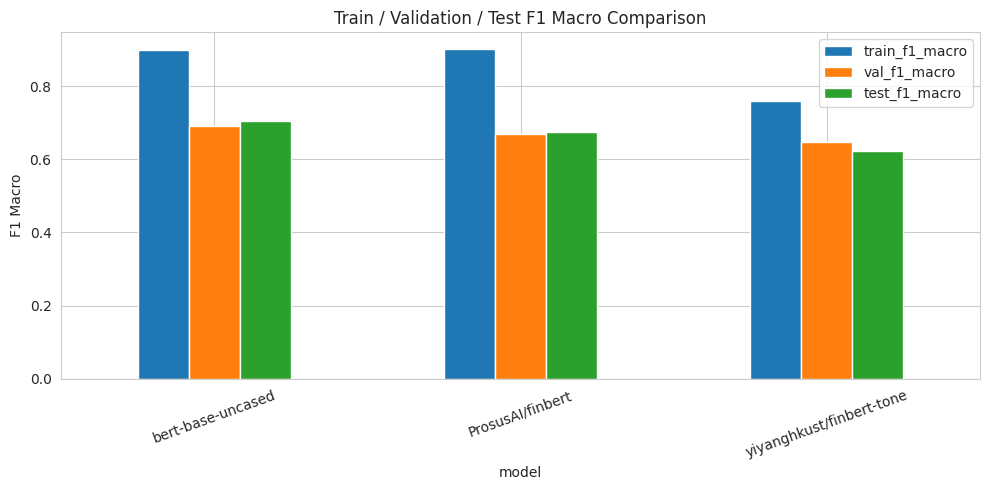

In [66]:
# =========================================================
# CELL 17: F1 Macro comparison bar chart
# =========================================================
ax = results_df.plot(
    x="model",
    y=["train_f1_macro", "val_f1_macro", "test_f1_macro"],
    kind="bar",
    figsize=(10, 5)
)
plt.title("Train / Validation / Test F1 Macro Comparison")
plt.ylabel("F1 Macro")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/model_f1_comparison.png", dpi=300)
plt.show()

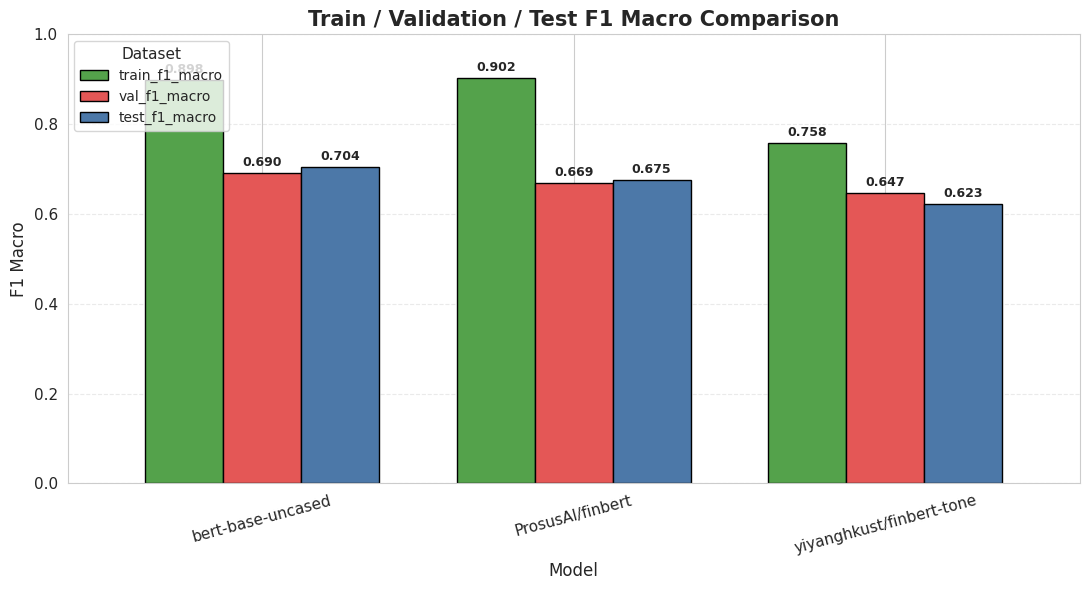

In [67]:
# =========================================================
# CELL 17: F1 Macro comparison bar chart (Professional)
# =========================================================
ax = results_df.plot(
    x="model",
    y=["train_f1_macro", "val_f1_macro", "test_f1_macro"],
    kind="bar",
    figsize=(11, 6),
    color=["#54A24B", "#E45756", "#4C78A8"],
    edgecolor="black",
    width=0.75
)

plt.title("Train / Validation / Test F1 Macro Comparison", fontsize=15, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("F1 Macro", fontsize=12)
plt.xticks(rotation=15, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, 1.0)
plt.legend(title="Dataset", fontsize=10, title_fontsize=11, loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/model_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

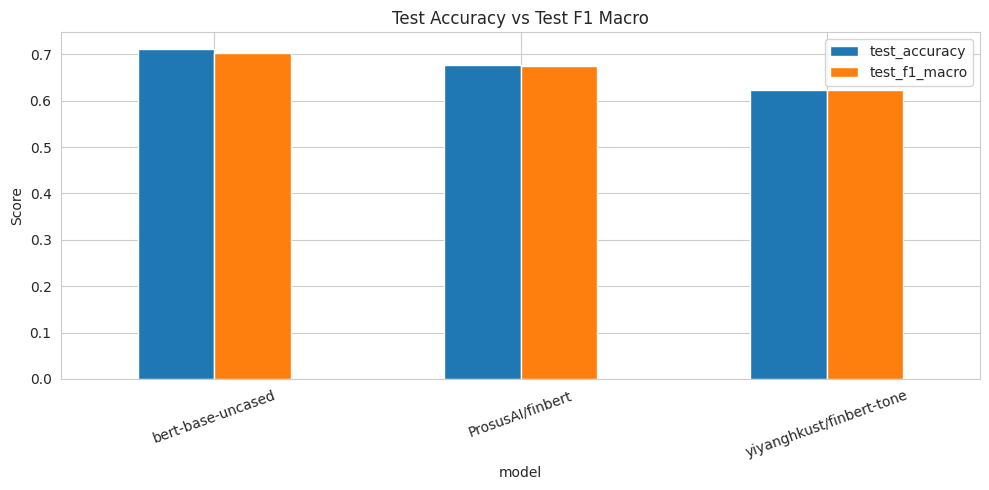

In [68]:
# =========================================================
# CELL 18: Test Accuracy vs Test F1 Macro
# =========================================================
ax = results_df.plot(
    x="model",
    y=["test_accuracy", "test_f1_macro"],
    kind="bar",
    figsize=(10, 5)
)
plt.title("Test Accuracy vs Test F1 Macro")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/test_accuracy_vs_f1.png", dpi=300)
plt.show()

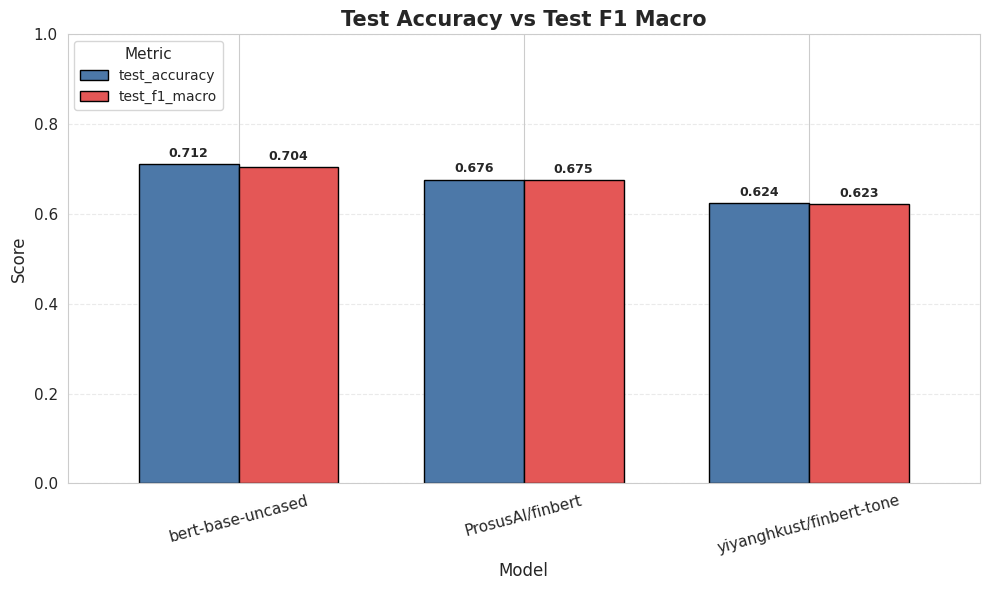

In [69]:
# =========================================================
# CELL 18: Test Accuracy vs Test F1 Macro (Professional)
# =========================================================
ax = results_df.plot(
    x="model",
    y=["test_accuracy", "test_f1_macro"],
    kind="bar",
    figsize=(10, 6),
    color=["#4C78A8", "#E45756"],
    edgecolor="black",
    width=0.7
)

plt.title("Test Accuracy vs Test F1 Macro", fontsize=15, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=15, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, 1.0)
plt.legend(title="Metric", fontsize=10, title_fontsize=11, loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/test_accuracy_vs_f1.png", dpi=300, bbox_inches="tight")
plt.show()

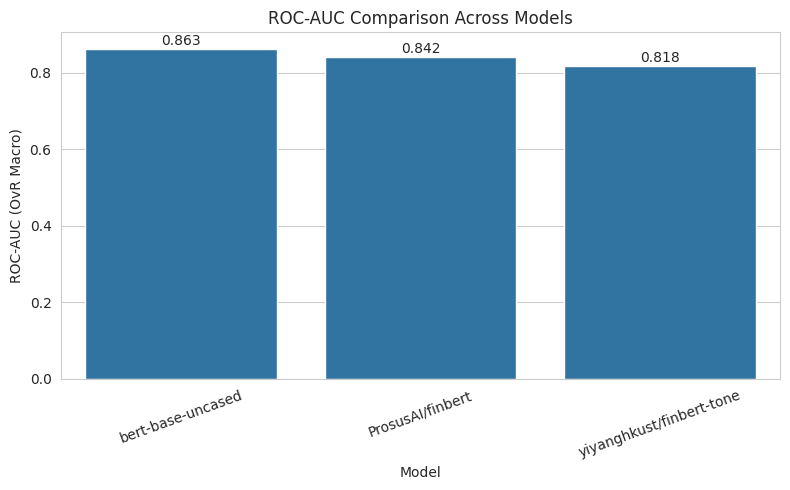

In [70]:
# =========================================================
# CELL 19: ROC-AUC comparison bar chart
# =========================================================
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=results_df, x="model", y="test_roc_auc_ovr_macro")
plt.title("ROC-AUC Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("ROC-AUC (OvR Macro)")
plt.xticks(rotation=20)

for i, v in enumerate(results_df["test_roc_auc_ovr_macro"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig("outputs/test_roc_auc_comparison_clean.png", dpi=300)
plt.show()

ROC files found: ['ProsusAI_finbert_roc_auc.png', 'bert_base_uncased_roc_auc.png', 'yiyanghkust_finbert_tone_roc_auc.png']


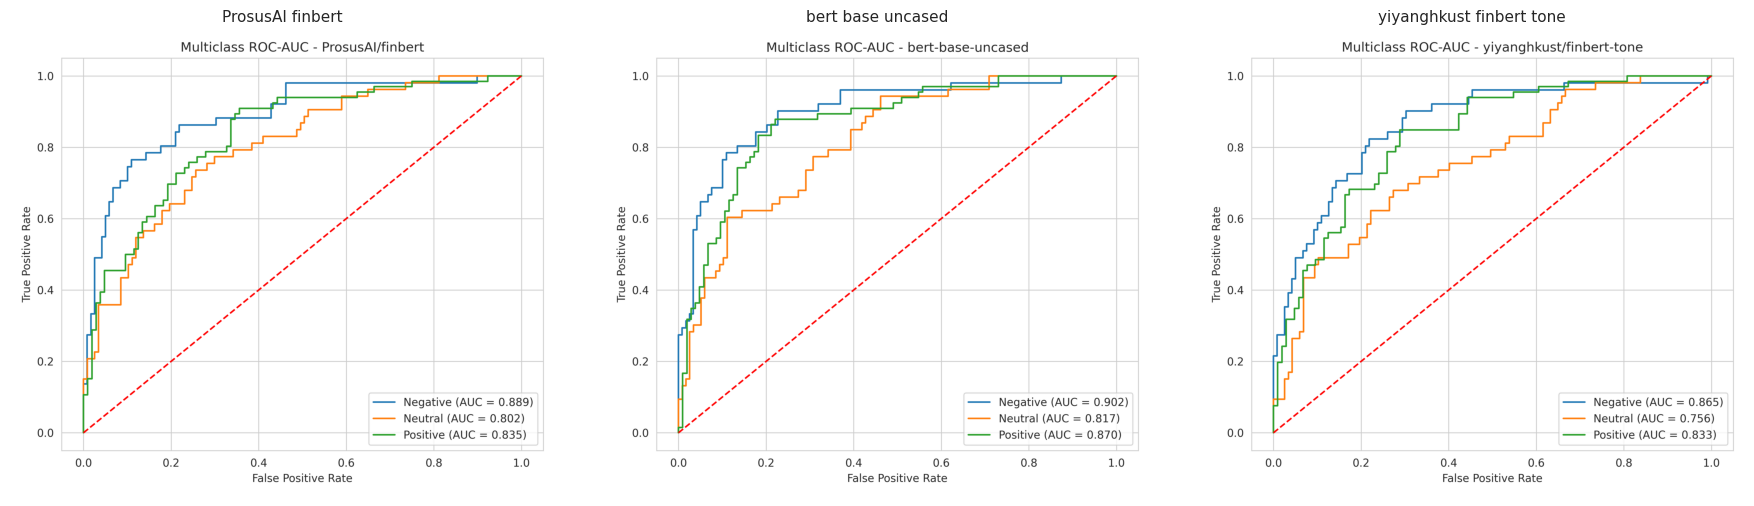

In [71]:
# =========================================================
# CELL 20: Display all ROC curve images
# =========================================================
import os
import math
import matplotlib.image as mpimg

roc_folder = "outputs/roc_curves"
image_files = sorted([f for f in os.listdir(roc_folder) if f.lower().endswith(".png")])

print("ROC files found:", image_files)

if len(image_files) == 0:
    print("No ROC images found.")
else:
    n_items = len(image_files)
    n_cols = min(3, n_items)
    n_rows = math.ceil(n_items / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    for ax, img_name in zip(axes, image_files):
        img_path = os.path.join(roc_folder, img_name)
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(img_name.replace("_roc_auc.png", "").replace("_", " "), fontsize=11)
        ax.axis("off")

    for i in range(len(image_files), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

Confusion matrix files found: ['ProsusAI_finbert_confusion_matrix.png', 'bert_base_uncased_confusion_matrix.png', 'yiyanghkust_finbert_tone_confusion_matrix.png']


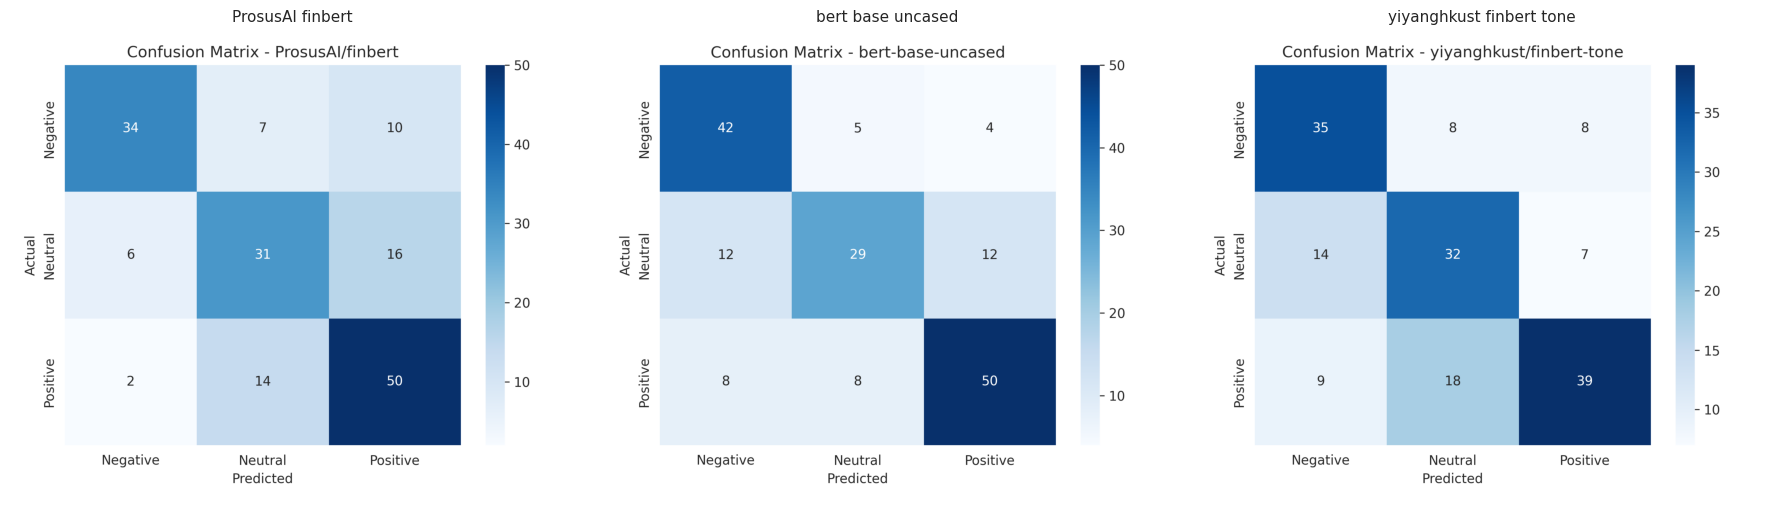

In [72]:
# =========================================================
# CELL 21: Display all confusion matrix images
# =========================================================
cm_folder = "outputs/confusion_matrices"
image_files = sorted([f for f in os.listdir(cm_folder) if f.lower().endswith(".png")])

print("Confusion matrix files found:", image_files)

if len(image_files) == 0:
    print("No confusion matrix images found.")
else:
    n_items = len(image_files)
    n_cols = min(3, n_items)
    n_rows = math.ceil(n_items / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    for ax, img_name in zip(axes, image_files):
        img_path = os.path.join(cm_folder, img_name)
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(img_name.replace("_confusion_matrix.png", "").replace("_", " "), fontsize=11)
        ax.axis("off")

    for i in range(len(image_files), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

Loss curve files found: ['ProsusAI_finbert_loss_curve.png', 'bert_base_uncased_loss_curve.png', 'yiyanghkust_finbert_tone_loss_curve.png']


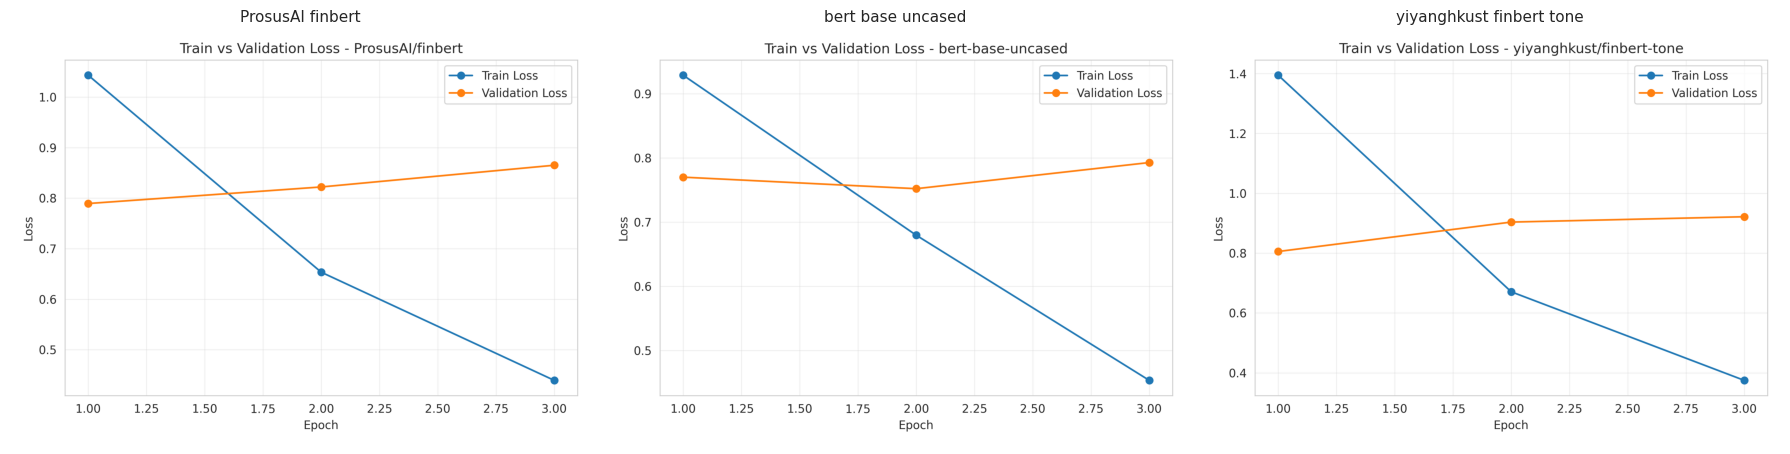

In [73]:
# =========================================================
# CELL 22: Display all loss curve images
# =========================================================
loss_folder = "outputs/loss_curves"
image_files = sorted([f for f in os.listdir(loss_folder) if f.lower().endswith(".png")])

print("Loss curve files found:", image_files)

if len(image_files) == 0:
    print("No loss curve images found.")
else:
    n_items = len(image_files)
    n_cols = min(3, n_items)
    n_rows = math.ceil(n_items / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    for ax, img_name in zip(axes, image_files):
        img_path = os.path.join(loss_folder, img_name)
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(img_name.replace("_loss_curve.png", "").replace("_", " "), fontsize=11)
        ax.axis("off")

    for i in range(len(image_files), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [74]:
# =========================================================
# CELL 23: Show sample error analysis from each model
# =========================================================
for safe_name in results_df["safe_name"]:
    file_path = f"outputs/error_analysis/{safe_name}_error_analysis.csv"
    print("\n" + "=" * 80)
    print(f"Error Analysis: {safe_name}")
    print("=" * 80)
    if os.path.exists(file_path):
        err_df = pd.read_csv(file_path)
        print(err_df.head(10))
    else:
        print("Error analysis file not found:", file_path)


Error Analysis: bert_base_uncased
                                                text true_label pred_label
0  nepal eager to import improved rice varieties ...   Positive    Neutral
1  gold edges down as investors turn cautious gol...   Positive   Negative
2  bangladesh's vaccine export dreams on hold ove...   Positive   Negative
3  biman to be smart airline in 'smart bangladesh...    Neutral   Positive
4  embattled beximco limited seeks tk400cr fresh ...   Negative   Positive
5  omera, beximco seek extension for lpg export t...    Neutral   Positive
6  fresh data show us consumers still strained by...    Neutral   Positive
7  global coal exports post rare decline in 2025 ...   Positive   Negative
8  budget fy25: bidi workers seek withdrawal of d...    Neutral   Negative
9  no recession risk for us economy as a whole af...   Positive   Negative

Error Analysis: ProsusAI_finbert
                                                text true_label pred_label
0  bhutan cargo stuck at burima

In [75]:
import pandas as pd

# =========================================================
# STEP 1: Initialize list
# =========================================================
comparison_data = []

# =========================================================
# STEP 2: Loop over stored results (all_results থেকে)
# =========================================================
for res in all_results:
    comparison_data.append({
        "Model": res["model"],
        "Test Accuracy": res["test_accuracy"],
        "Precision (Macro)": res.get("precision_macro", None),
        "Recall (Macro)": res.get("recall_macro", None),
        "F1 Macro": res["test_f1_macro"],
        "F1 Weighted": res["test_f1_weighted"],
        "ROC-AUC (OvR Macro)": res["test_roc_auc_ovr_macro"],
        "Neg AUC": res["auc_negative"],
        "Neu AUC": res["auc_neutral"],
        "Pos AUC": res["auc_positive"]
    })

# =========================================================
# STEP 3: Create DataFrame
# =========================================================
comparison_df = pd.DataFrame(comparison_data)

# sort by best model
comparison_df = comparison_df.sort_values(by="F1 Macro", ascending=False)

# =========================================================
# STEP 4: Show Table
# =========================================================
print("\n=== MODEL COMPARISON TABLE ===")
display(comparison_df)

# =========================================================
# STEP 5: Save Table
# =========================================================
comparison_df.to_csv("outputs/final_model_comparison_table.csv", index=False)

print("\nSaved to: outputs/final_model_comparison_table.csv")


=== MODEL COMPARISON TABLE ===


,Model,Test Accuracy,Precision (Macro),Recall (Macro),F1 Macro,F1 Weighted,ROC-AUC (OvR Macro),Neg AUC,Neu AUC,Pos AUC
0,bert-base-uncased,0.711765,None,None,0.703822,0.707467,0.862900,0.902126,0.816965,0.869610
1,ProsusAI/finbert,0.676471,None,None,0.675295,0.676850,0.842372,0.889438,0.802451,0.835227
2,yiyanghkust/finbert-tone,0.623529,None,None,0.622926,0.624770,0.818031,0.864722,0.756330,0.833042



Saved to: outputs/final_model_comparison_table.csv


In [76]:
# =========================================================
# CLASS-WISE F1 TABLE (manual extraction needed)
# =========================================================

classwise_data = []

for model_name in model_names:
    safe_name = model_name.replace("/", "_").replace("-", "_")

    file_path = f"outputs/classification_reports/{safe_name}_classification_report.txt"

    if os.path.exists(file_path):
        with open(file_path, "r") as f:
            print(f"\n=== {model_name} ===")
            print(f.read())


=== bert-base-uncased ===
              precision    recall  f1-score   support

    Negative       0.68      0.82      0.74        51
     Neutral       0.69      0.55      0.61        53
    Positive       0.76      0.76      0.76        66

    accuracy                           0.71       170
   macro avg       0.71      0.71      0.70       170
weighted avg       0.71      0.71      0.71       170


=== ProsusAI/finbert ===
              precision    recall  f1-score   support

    Negative       0.81      0.67      0.73        51
     Neutral       0.60      0.58      0.59        53
    Positive       0.66      0.76      0.70        66

    accuracy                           0.68       170
   macro avg       0.69      0.67      0.68       170
weighted avg       0.68      0.68      0.68       170


=== yiyanghkust/finbert-tone ===
              precision    recall  f1-score   support

    Negative       0.60      0.69      0.64        51
     Neutral       0.55      0.60      0.5

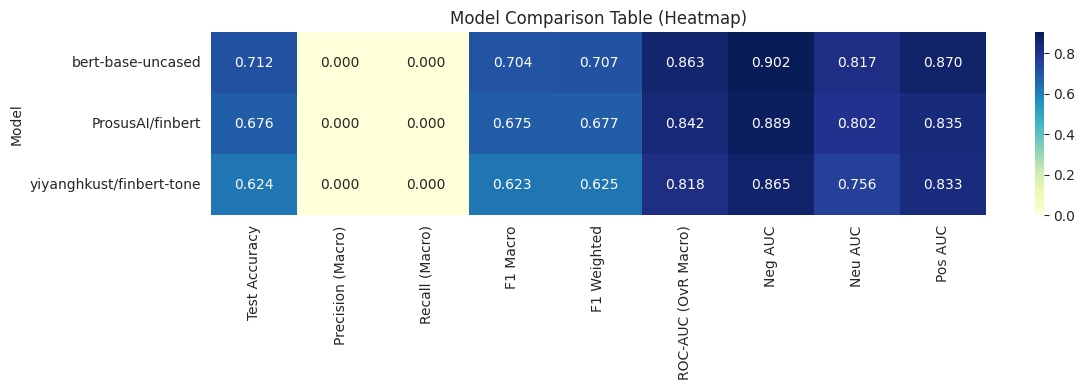

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Model কে index করো
heatmap_df = comparison_df.set_index("Model").copy()

# সব possible numeric column number এ convert করো
for col in heatmap_df.columns:
    heatmap_df[col] = pd.to_numeric(heatmap_df[col], errors="coerce")

# optional: NaN থাকলে fill করো
heatmap_df = heatmap_df.fillna(0)

plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Model Comparison Table (Heatmap)")
plt.tight_layout()
plt.savefig("outputs/model_comparison_heatmap.png", dpi=300)
plt.show()

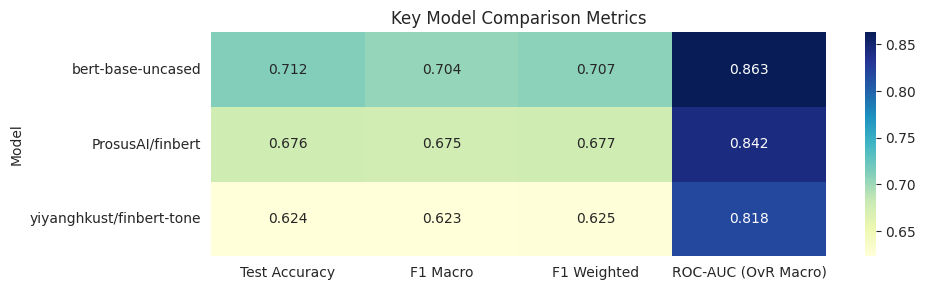

In [78]:
heatmap_df = comparison_df[[
    "Model",
    "Test Accuracy",
    "F1 Macro",
    "F1 Weighted",
    "ROC-AUC (OvR Macro)"
]].set_index("Model").copy()

for col in heatmap_df.columns:
    heatmap_df[col] = pd.to_numeric(heatmap_df[col], errors="coerce")

plt.figure(figsize=(10, 3))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Key Model Comparison Metrics")
plt.tight_layout()
plt.savefig("outputs/model_comparison_heatmap_clean.png", dpi=300)
plt.show()